## Glacial Lake Mapping in Southeast Iceland using Landsat via Google Earth Engine

Replicates the Sentinel-2 OBIA workflow (`1_OBIA_lakes_S1S2.ipynb`) using Landsat instead,
to extend the lake time series back to the 1980s. No SAR satellite has the same temporal resolution as Landsat, therefore, SAR data has been replaced with the addition of TIR, NDDI and elevation.

Based on [Dabiri et al 2021](https://austriaca.at/0xc1aa5576%200x003c9b50.pdf).

**Workflow per year (1984–2015):**
  1. Load Landsat summer composite (April–October) via Google Earth Engine
  2. Load ArcticDEM V4 via Google Earth Engine
  3. Compute indices NDVI, NDWI, NDDI, NDSI, Brightness
  4. Segment image using SLIC 
  5. Classify water segments using indices and elevation
  6. Export polygon outlines per year as GeoPackage

**Data used:**
- 1984–1998: Landsat 5 TM (`LANDSAT/LT05/C02/T1_TOA`)
- 1999–2012: Landsat 7 ETM+ (`LANDSAT/LE07/C02/T1_TOA`) — note SLC-off after 2003
- 2013–2021: Landsat 8 OLI (`LANDSAT/LC08/C02/T1_TOA`)
- 2022+:     Landsat 9 OLI-2 (`LANDSAT/LC09/C02/T1_TOA`)
- ArcticDEM V4 (`UMN/PGC/ArcticDEM/V4/2m_mosaic`)

Imports

In [1]:
import os
import numpy as np
import rasterio
from rasterio.crs import CRS
from rasterio.warp import reproject, Resampling
import geopandas as gpd
from shapely.geometry import shape
from rasterio.features import shapes as rio_shapes
from skimage.segmentation import slic, find_boundaries
from skimage.measure import regionprops
import matplotlib.pyplot as plt
import ee
import geemap
from tqdm import tqdm
import warnings
import matplotlib.patches as mpatches
from config import OUT_DIR, DATA_DIR, OBIA_DIR
warnings.filterwarnings("ignore")

### Configuration

Connect to GEE

In [2]:
# ee.Authenticate(force=True) # uncomment to force re-authentication 
ee.Authenticate()
ee.Initialize()

In [3]:
# Bounding box: Southeast Iceland (Vatnajökull glacier lake area)
BBOX = {
    "west":  -16.5,
    "south":  63.97,
    "east":  -16.1,
    "north":  64.2,
}

# convert to GEE geometry 
AOI = ee.Geometry.Rectangle(
    [BBOX["west"], BBOX["south"], BBOX["east"], BBOX["north"]]
)

# Reproject to UTM zone 27N (EPSG:32627) 
TARGET_CRS = "EPSG:32627" 

# Temporal range: summer months per year
YEARS = list(range(1984, 2016))  # 1984–2015 inclusive
# Wider summer window than Sentinel-2 to increase scene availability
SUMMER_START_MM_DD = "04-01"
SUMMER_END_MM_DD   = "10-31"

# Cloud masking
MAX_CLOUD_COVER = 50  

# Output resolution
SCALE_M = 30

Segmentation and classification parameters


In [4]:
SEG_PARAMS = {            # parameters for SLIC segmentation
    "n_segments":  1500,  # increased from Sentinel to capture more detail in larger Landsat pixels
    "compactness": 0.4,   
    "sigma":       0.8,   
}

# Classification thresholds
NDWI_THRESHOLD       = 0.2
NDVI_THRESHOLD       = -0.1
NDDI_THRESHOLD       = -0.7
MAX_ELEVATION_M      = 125
BRIGHTNESS_THRESHOLD = 0.3
MIN_LAKE_AREA_M2     = 10_000     
MAX_LAKE_AREA_M2     = 35_000_000  # upper bound to exclude sea/ocean

WATER_FRACTION_THRESHOLD = 0.7    # segment needs >70% water pixels to be classified as water
                                  # lower → more inclusive (larger outlines)
                                  # higher → more conservative (smaller, cleaner outlines)

### Landsat data loading
Automatically picks the right Landsat mission and band names for each year.
All missions use top of atmosphere.
Uses the Fmask QA_PIXEL band.
Bits 1, 2, 3, 4 flag dilated cloud, cirrus, cloud, cloud shadow.

In [5]:
def get_landsat_collection(year: int):
    if year < 1999:
        collection_id = "LANDSAT/LT05/C02/T1_TOA"
        bands = {"blue": "B1", "green": "B2", "red": "B3",
                 "nir": "B4", "swir1": "B5", "tir" : "B6", "qa": "QA_PIXEL"}
    elif year < 2013:
        collection_id = "LANDSAT/LE07/C02/T1_TOA"
        bands = {"blue": "B1", "green": "B2", "red": "B3",
                 "nir": "B4", "swir1": "B5", "tir" : "B6_VCID_1", "qa": "QA_PIXEL"}
    elif year < 2022:
        collection_id = "LANDSAT/LC08/C02/T1_TOA"
        bands = {"blue": "B2", "green": "B3", "red": "B4",
                 "nir": "B5", "swir1": "B6", "tir" : "B11", "qa": "QA_PIXEL"}
    else:
        collection_id = "LANDSAT/LC09/C02/T1_TOA"
        bands = {"blue": "B2", "green": "B3", "red": "B4",
                 "nir": "B5", "swir1": "B6", "tir" : "B11", "qa": "QA_PIXEL"}
    return collection_id, bands


def mask_landsat_clouds(image: ee.Image) -> ee.Image:
    bqa = image.select("QA_PIXEL")
    cloud        = bqa.bitwiseAnd(1 << 4).neq(0)
    cloud_shadow = bqa.bitwiseAnd(1 << 3).neq(0)
    return image.updateMask(cloud.Or(cloud_shadow).Not())


def build_landsat_composite(year: int):
    """Build cloud-masked median summer composite."""
    collection_id, bands = get_landsat_collection(year)
    col = (
        ee.ImageCollection(collection_id)
        .filterBounds(AOI)
        .filterDate(f"{year}-{SUMMER_START_MM_DD}", f"{year}-{SUMMER_END_MM_DD}")
        .filter(ee.Filter.lt("CLOUD_COVER", MAX_CLOUD_COVER))
        .map(mask_landsat_clouds)
    )
    n_scenes = col.size().getInfo()
    print(f"  [{collection_id.split('/')[1]}] {n_scenes} scenes")
    if n_scenes == 0:
        return None, None
    band_from = [bands["blue"], bands["green"], bands["red"],
                 bands["nir"],  bands["swir1"], bands["tir"]]
    band_to   = ["blue", "green", "red", "nir", "swir1", "tir"]
    return col.select(band_from, band_to).median().clip(AOI), band_to


def download_landsat_composite(year: int, out_path: str) -> str:
    if os.path.exists(out_path):
        print(f"  [LS] Cached: {out_path}")
        return out_path
    print(f"  [LS] Building composite for {year}...")
    composite, _ = build_landsat_composite(year)
    if composite is None:
        raise ValueError(f"No valid Landsat scenes for {year}")
    geemap.ee_export_image(
        composite, filename=out_path, scale=SCALE_M,
        region=AOI, crs=TARGET_CRS, file_per_band=False,
    )
    print(f"  [LS] Downloaded: {out_path}")
    return out_path

### ArcticDEM download

Collection `UMN/PGC/ArcticDEM/V4/2m_mosaic` is downloaded at 30 m via GEE
(server-side resampling from 2 m), then aligned to the Landsat pixel grid locally.

In [16]:
def download_arcticdem(out_path: str, landsat_ref_path: str) -> np.ndarray:
    """
    Download ArcticDEM V4 2m mosaic, resampled to 30 m Landsat grid.
    Returns elevation as float32 array (metres above WGS84 ellipsoid).
    Cached to disk after first download.
    """
    if not os.path.exists(out_path):
        print("  [DEM] Downloading ArcticDEM V4 mosaic from GEE...")
        dem = ee.Image("UMN/PGC/ArcticDEM/V4/2m_mosaic").select("elevation").clip(AOI)
        geemap.ee_export_image(
            dem, filename=out_path, scale=SCALE_M,
            region=AOI, crs=TARGET_CRS, file_per_band=False,
        )
        print(f"  [DEM] Downloaded")
    else:
        print(f"  [DEM] Cached")

    with rasterio.open(landsat_ref_path) as ls:
        dst_crs, dst_transform = ls.crs, ls.transform
        dst_w, dst_h = ls.width, ls.height

    with rasterio.open(out_path) as dem_src:
        elev = np.zeros((dst_h, dst_w), dtype=np.float32)
        reproject(
            source=rasterio.band(dem_src, 1), destination=elev,
            src_transform=dem_src.transform, src_crs=dem_src.crs,
            dst_transform=dst_transform, dst_crs=dst_crs,
            resampling=Resampling.bilinear,
        )

    elev = np.where(elev < -1000, np.nan, elev)  # ArcticDEM nodata = -9999
    print(f"  [DEM] Elevation: {np.nanmin(elev):.1f} to {np.nanmax(elev):.1f} m")
    return elev

### Compute indices


In [17]:
def compute_indices(blue, green, red, nir, swir1, tir):
    """
    Compute Landsat spectral indices (0-1 reflectance).
    NDVI  = (NIR - Red)    / (NIR + Red)       vegetation index
    NDWI  = (Green - NIR)  / (Green + NIR)     water index
    NDSI  = (Green - SWIR1)/ (Green + SWIR1)   snow/ice (> 0.4 = snow)
    NDDI  = (SWIR1 - TIR_norm) / (SWIR1 + TIR_norm)  dry/wet surface
            TIR normalised to 0-1 before use (raw values are in Kelvin)
            Water = cold (low TIR_norm) + low SWIR → NDDI < 0
    Brightness = mean(Blue, Green, Red)
    Returns: ndvi, ndwi, ndsi, nddi, brightness (all float32)
    """
    eps = 1e-10
    ndvi       = (nir   - red)   / (nir   + red   + eps)
    ndwi       = (green - nir)   / (green + nir   + eps)
    ndsi       = (green - swir1) / (green + swir1 + eps)
    brightness = (blue + green + red) / 3.0

    # Normalise TIR (Kelvin) to 0-1 within the scene before NDDI
    tir_min  = np.nanpercentile(tir, 2)
    tir_max  = np.nanpercentile(tir, 98)
    tir_norm = np.clip((tir - tir_min) / (tir_max - tir_min + eps), 0, 1)
    nddi     = (swir1 - tir_norm) / (swir1 + tir_norm + eps)

    return (
        np.clip(ndvi, -1, 1).astype(np.float32),
        np.clip(ndwi, -1, 1).astype(np.float32),
        np.clip(ndsi, -1, 1).astype(np.float32),
        np.clip(nddi, -1, 1).astype(np.float32),
        brightness.astype(np.float32),
    )

### Segmentation

In [18]:
def segment_image(blue, green, red, nir, swir1, ndvi, ndwi, ndsi, nddi, elevation, brightness,
                  seg_params: dict) -> np.ndarray:
    """
    Segment the image using SLIC superpixels.
    All features are normalised to [0, 1] before stacking.

    """
    def norm(arr):
        mn, mx = np.nanpercentile(arr, 2), np.nanpercentile(arr, 98)
        if mx == mn:
            return np.zeros_like(arr, dtype=np.float32)
        return np.clip((arr - mn) / (mx - mn), 0, 1).astype(np.float32)

    feature_stack = np.dstack([
        norm(blue), norm(green), norm(red), norm(nir), norm(swir1), 
        norm(ndvi), norm(ndwi), norm(ndsi), norm(nddi), norm(elevation), norm(brightness)
    ])
    feature_stack = np.nan_to_num(feature_stack, nan=0.0)

    segments = slic(
        feature_stack,
        n_segments=seg_params["n_segments"],
        compactness=seg_params["compactness"],
        sigma=seg_params["sigma"],
        start_label=1,
        channel_axis=-1,
    )
    return segments

### Classification


In [19]:
def classify_water_segments(segments, ndwi, ndvi, nddi, elevation, brightness, seg_params,
                             water_fraction_threshold=None) -> np.ndarray:
    """
    Classify a segment as water if more than `water_fraction_threshold`
    of its valid pixels pass the pixel-level criteria.
    This aligns the segment output much more closely with the pixel mask.
    """
    water_mask = np.zeros_like(segments, dtype=np.uint8)

    # Pixel-level water criteria 
    px_is_water = (
        np.where(np.isnan(ndwi),      False, ndwi      >= NDWI_THRESHOLD) &
        np.where(np.isnan(nddi),      False, nddi      <  NDDI_THRESHOLD) &
        np.where(np.isnan(elevation), False, elevation <  MAX_ELEVATION_M)&
        np.where(np.isnan(ndvi),      False, ndvi      <  NDVI_THRESHOLD) & 
        np.where(np.isnan(brightness), False, brightness < BRIGHTNESS_THRESHOLD)
    )

    for prop in regionprops(segments):
        px_mask  = segments == prop.label
        size_px  = int(np.sum(px_mask))

        if size_px < seg_params.get("min_size_px", 1):
            continue

        # Fraction of pixels in this segment that pass pixel-level water test
        valid_px    = np.sum(~np.isnan(ndwi[px_mask]))
        water_px    = np.sum(px_is_water[px_mask])

        if valid_px == 0:
            continue

        fraction = water_px / valid_px

        if fraction >= water_fraction_threshold:
            water_mask[px_mask] = 1

    return water_mask

### Vectorisation


In [20]:
def vectorise_water_mask(water_mask: np.ndarray,
                          transform,
                          src_crs: CRS,
                          year: int) -> gpd.GeoDataFrame:
    """
    Convert binary water mask to polygon geometries.
    Filters by area. Reprojects to TARGET_CRS.
    """
    polys = [
        shape(geom)
        for geom, val in rio_shapes(
            water_mask,
            mask=water_mask.astype(np.uint8),
            transform=transform,
        )
        if val == 1
    ]

    if not polys:
        print(f"  ⚠ No water polygons found for {year}")
        return gpd.GeoDataFrame(
            columns=["geometry", "year", "area_m2"], crs=src_crs
        )

    # Area filter
    gdf = gpd.GeoDataFrame({"geometry": polys}, crs=src_crs)
    gdf = gdf.to_crs(TARGET_CRS)
    gdf["area_m2"] = gdf.geometry.area
    gdf["year"]    = year

    gdf = gdf[
        (gdf["area_m2"] >= MIN_LAKE_AREA_M2) &
        (gdf["area_m2"] <= MAX_LAKE_AREA_M2)
    ].copy().reset_index(drop=True)

    print(
        f"  ✓ {len(gdf)} lake polygons detected for {year} "
        f"(total area: {gdf['area_m2'].sum()/1e6:.2f} km²)"
    )
    return gdf

### Main pipeline

In [21]:
def process_year(year) -> gpd.GeoDataFrame:
    print(f"\n{'='*60}")
    print(f"  Processing year: {year}")
    print(f"{'='*60}")

    tif_path = os.path.join(OUT_DIR, f"composite_landsat_{year}.tif")
    dem_path = os.path.join(OUT_DIR, "arcticdem_v4_30m.tif")

    # 1. Download Landsat composite
    download_landsat_composite(year, tif_path)

    # 2. Load bands
    with rasterio.open(tif_path) as src:
        blue  = src.read(1).astype(np.float32)
        green = src.read(2).astype(np.float32)
        red   = src.read(3).astype(np.float32)
        nir   = src.read(4).astype(np.float32)
        swir1 = src.read(5).astype(np.float32)
        tir   = src.read(6).astype(np.float32)
        transform = src.transform
        src_crs   = src.crs
        nodata = (blue <= 0) | (tir <= 0)
        for arr in [blue, green, red, nir, swir1, tir]:
            arr[nodata] = np.nan

    print(f"  ↳ Image shape: {blue.shape}")

    # 3. Download and align DEM to this year's Landsat grid
    elev_yr = download_arcticdem(dem_path, tif_path)

    # 4. Compute indices
    print("  ↳ Computing spectral indices...")
    ndvi, ndwi, ndsi, nddi, brightness = compute_indices(blue, green, red, nir, swir1, tir)

    # 5. Segment
    print(f"  ↳ Segmenting (SP={SEG_PARAMS['n_segments']})...")
    segments = segment_image(
        blue, green, red, nir, swir1, ndvi, ndsi, ndwi, nddi,  elev_yr, brightness, SEG_PARAMS
    )

    # 6. Classify
    print("  ↳ Classifying water segments...")
    water_mask = classify_water_segments(
        segments, ndwi, ndvi, nddi, elev_yr, brightness, SEG_PARAMS,
        water_fraction_threshold=WATER_FRACTION_THRESHOLD
    )

    # 7. Vectorise
    print("  ↳ Vectorising water mask...")
    gdf = vectorise_water_mask(water_mask, transform, src_crs, year)

    return gdf



### Optional: check scene availability before running the full pipeline

Run this cell first to see how many valid Landsat scenes exist per year before committing to the full download.

In [22]:
# print(f"{'Year':<6} {'Mission':<12} {'Scenes found':>12}")
# print("-" * 32)

# for year in YEARS:
#     collection_id, bands = get_landsat_collection(year)
#     mission = collection_id.split("/")[1]  # e.g. LT05, LE07, LC08

#     col = (
#         ee.ImageCollection(collection_id)
#         .filterBounds(AOI)
#         .filterDate(f"{year}-{SUMMER_START_MM_DD}", f"{year}-{SUMMER_END_MM_DD}")
#         .filter(ee.Filter.lt("CLOUD_COVER", MAX_CLOUD_COVER))
#     )
#     n = col.size().getInfo()
#     flag = "  ⚠ no scenes" if n == 0 else ""
#     print(f"{year:<6} {mission:<12} {n:>12}{flag}")

### Run pipeline

In [23]:
# all_years_gdfs = []
# for year in tqdm(YEARS, desc="Processing years"):
#     try:
#         gdf = process_year(year)
#         if len(gdf) > 0:
#             out_gpkg = os.path.join(OBIA_DIR, f"glacial_lakes_{year}.gpkg")
#             gdf.to_file(out_gpkg, driver="GPKG")
#             print(f"  ✓ Saved: {out_gpkg}")
#             all_years_gdfs.append(gdf)
#         else:
#             print(f"  ⚠ No lakes detected for {year} — skipping save")
#     except Exception as e:
#         print(f"  ✗ Error processing {year}: {e}")

### Check image
Plot indices for one year to evaluate the thresholds.

  [DEM] Cached
  [DEM] Elevation: 59.9 to 1356.3 m


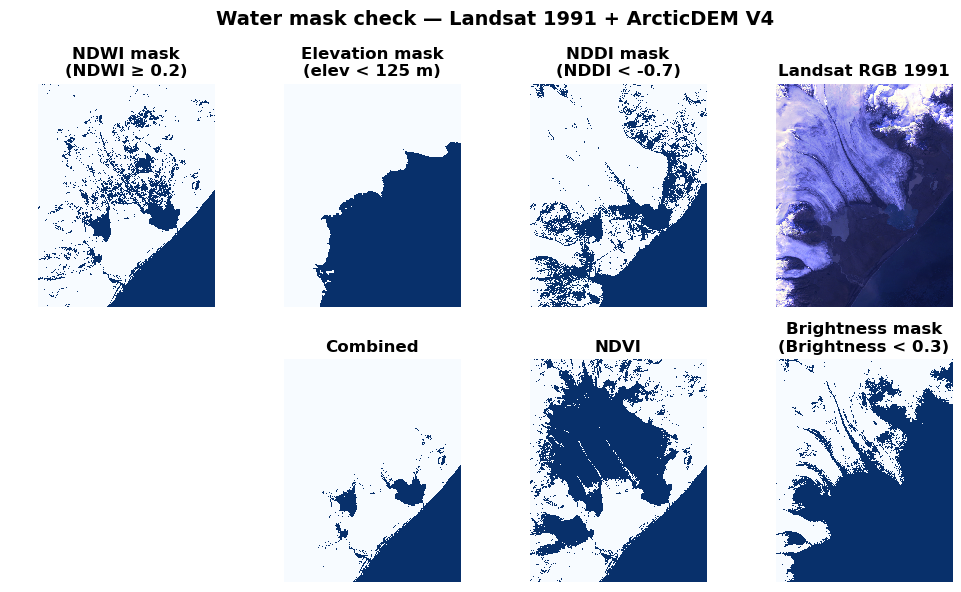

In [24]:
check_year = 1991
tif_path   = os.path.join(OUT_DIR, f"composite_landsat_{check_year}.tif")
dem_path = os.path.join(OUT_DIR, "arcticdem_v4_30m.tif")

# Load bands
with rasterio.open(tif_path) as src:
    blue  = src.read(1).astype(np.float32)
    green = src.read(2).astype(np.float32)
    red   = src.read(3).astype(np.float32)
    nir   = src.read(4).astype(np.float32)
    swir1 = src.read(5).astype(np.float32)
    tir   = src.read(6).astype(np.float32)
    profile = src.profile  

nodata = (blue <= 0) | (nir <= 0)
for arr in [blue, green, red, nir, swir1, tir]:
    arr[nodata] = np.nan

eps  = 1e-10
ndwi = np.clip((green - nir)   / (green + nir   + eps), -1, 1)
ndvi = np.clip((nir   - red)   / (nir   + red   + eps), -1, 1)
ndsi = np.clip((green - swir1) / (green + swir1 + eps), -1, 1)
brightness = (blue + green + red) / 3.0
elevation = download_arcticdem(dem_path, tif_path)

# Normalise TIR to 0-1 range within the scene before NDDI
tir_norm = np.where(
    np.isnan(tir), np.nan,
    ((tir - np.nanpercentile(tir, 2)) /
     (np.nanpercentile(tir, 98) - np.nanpercentile(tir, 2) + eps))
).astype(np.float32)
tir_norm = np.clip(tir_norm, 0, 1)

nddi = np.where(
    np.isnan(swir1) | np.isnan(tir_norm),
    np.nan,
    np.clip((swir1 - tir_norm) / (swir1 + tir_norm + eps), -1, 1).astype(np.float32)
)

water_ndwi = np.where(np.isnan(ndwi), np.nan, (ndwi >= NDWI_THRESHOLD).astype(float))
water_elevation = np.where(np.isnan(elevation), np.nan, (elevation < MAX_ELEVATION_M).astype(float))
water_ndvi = np.where(np.isnan(ndvi), np.nan, (ndvi < NDVI_THRESHOLD).astype(float))
water_nddi = np.where(np.isnan(nddi), np.nan, (nddi < NDDI_THRESHOLD).astype(float))
water_brightness = np.where(np.isnan(brightness), np.nan, (brightness < BRIGHTNESS_THRESHOLD).astype(float))

water_combined_ndvi = np.where(
    np.isnan(ndwi) | np.isnan(nddi) | np.isnan(elevation) | np.isnan(ndvi),
    np.nan,
    (
        np.where(np.isnan(ndwi),      False, ndwi      >= NDWI_THRESHOLD)
        & np.where(np.isnan(nddi),    False, nddi      <  NDDI_THRESHOLD)
        & np.where(np.isnan(elevation),False, elevation <  MAX_ELEVATION_M)
        & np.where(np.isnan(ndvi), False, ndvi < NDVI_THRESHOLD)
        & np.where(np.isnan(brightness), False, brightness < BRIGHTNESS_THRESHOLD)
    ).astype(float)
)

# Download indices as tif
index_profile = profile.copy()
index_profile.update(count=1, dtype="float32", nodata=np.nan)
indices = {
    "ndwi": ndwi,
    "ndvi": ndvi,
    "ndsi": ndsi,
    "brightness": brightness,
    "elevation": elevation,
    "nddi": nddi,
    "brightness": brightness,
}

for name, arr in indices.items():
    out_path = os.path.join(OUT_DIR, f"{name}_{check_year}.tif")
    with rasterio.open(out_path, "w", **index_profile) as dst:
        dst.write(arr, 1)

#  plot figures
fig, axes = plt.subplots(2, 4, figsize=(10, 6))

# RGB
axes[0, 3].imshow(np.dstack([
    np.clip(red   / np.nanpercentile(red,   98), 0, 1),
    np.clip(green / np.nanpercentile(green, 98), 0, 1),
    np.clip(blue  / np.nanpercentile(blue,  98), 0, 1),
]), interpolation="nearest")
axes[0, 3].set_title(f"Landsat RGB {check_year}", fontweight="bold")
axes[0, 3].axis("off")

# NDWI mask
axes[0, 0].imshow(water_ndwi, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
axes[0, 0].set_title(f"NDWI mask\n(NDWI ≥ {NDWI_THRESHOLD})", fontweight="bold")
axes[0, 0].axis("off")

# Elevation mask
axes[0,1].imshow(water_elevation, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
axes[0,1].set_title(f"Elevation mask\n(elev < {MAX_ELEVATION_M} m)", fontweight="bold")
axes[0,1].axis("off")

# NDDI mask
axes[0,2].imshow(water_nddi, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
axes[0,2].set_title(f"NDDI mask\n(NDDI < {NDDI_THRESHOLD})", fontweight="bold")
axes[0,2].axis("off")

# Combined
axes[1,1].imshow(water_combined_ndvi, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
axes[1,1].set_title(f"Combined", fontweight="bold")
axes[1,1].axis("off")

# NDVI mask
axes[1,2].imshow(water_ndvi, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
axes[1,2].set_title(f"NDVI", fontweight="bold")
axes[1,2].axis("off")

# Brightness mask
axes[1,3].imshow(water_brightness, cmap="Blues", vmin=0, vmax=1, interpolation="nearest")
axes[1,3].set_title(f"Brightness mask\n(Brightness < {BRIGHTNESS_THRESHOLD})", fontweight="bold")
axes[1,3].axis("off")

axes[1,0].axis("off")

plt.suptitle(
    f"Water mask check — Landsat {check_year} + ArcticDEM V4",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
check_png = os.path.join(OUT_DIR, f"water_mask_check_{check_year}.png")
plt.savefig(check_png, dpi=150, bbox_inches="tight")
plt.show()

### Segmentation outlines check
Visualize the segmentations to examine different segmentation parameters. The indices plot above needs to be run first.

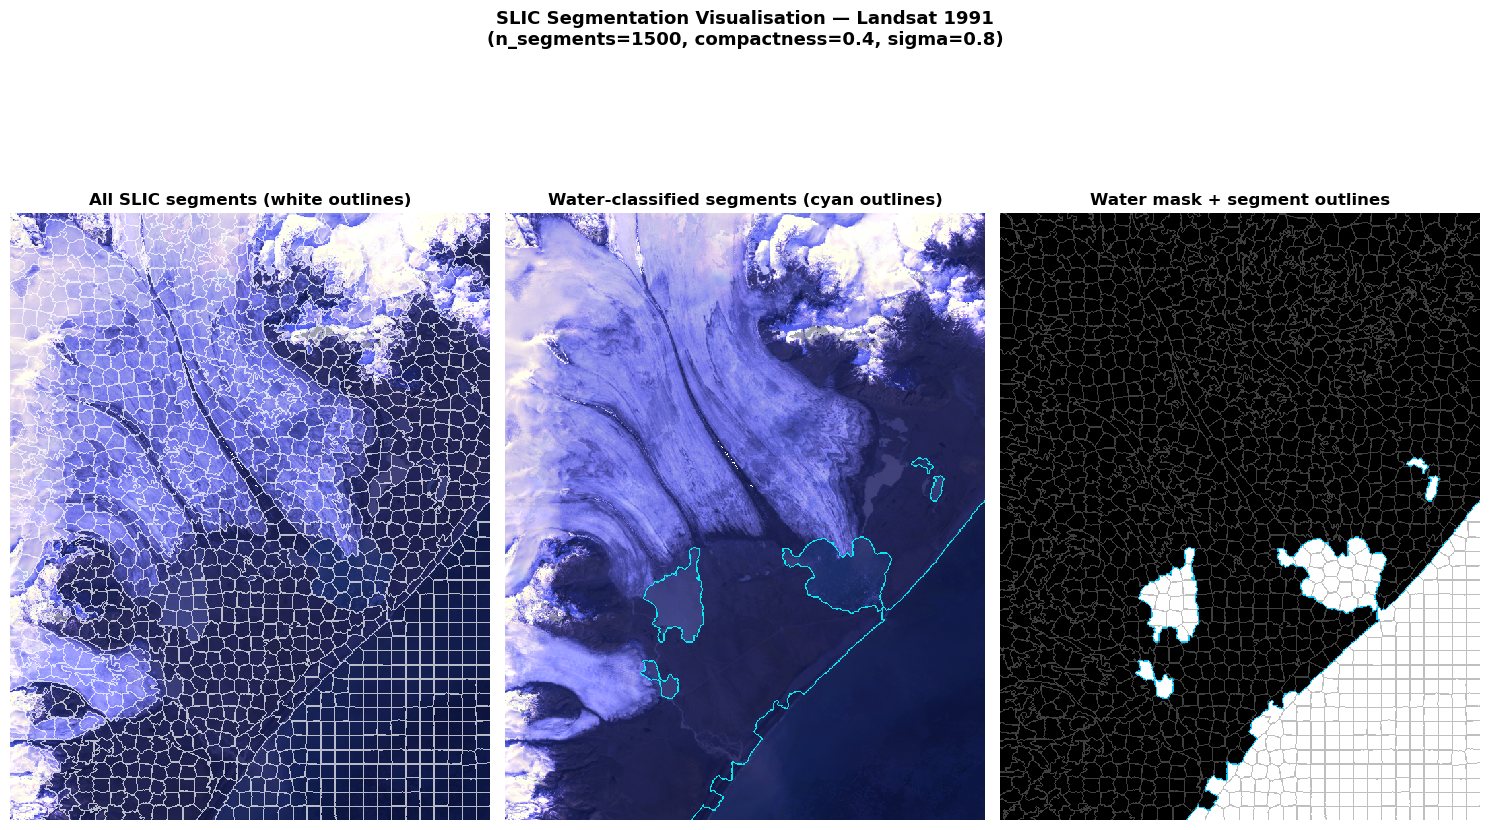

In [25]:
# Segment
def norm(arr):
    mn, mx = np.nanpercentile(arr, 2), np.nanpercentile(arr, 98)
    if mx == mn:
        return np.zeros_like(arr, dtype=np.float32)
    return np.clip((arr - mn) / (mx - mn), 0, 1).astype(np.float32)

feature_stack = np.nan_to_num(
    np.dstack([
        norm(blue), norm(green), norm(red), norm(nir),
        norm(ndvi), norm(ndwi), norm(nddi),
        norm(elevation), norm(brightness),
    ]),
    nan=0.0,
)

segments = slic(
    feature_stack,
    n_segments=SEG_PARAMS["n_segments"],
    compactness=SEG_PARAMS["compactness"],
    sigma=SEG_PARAMS["sigma"],
    start_label=1,
    channel_axis=-1,
)

# Classify
water_mask = classify_water_segments(
    segments, ndwi, ndvi, nddi, elevation, brightness, SEG_PARAMS,
    water_fraction_threshold=WATER_FRACTION_THRESHOLD,
)

# Build RGB
def rgb(r, g, b, p=98):
    """Stretch each channel to [0,1] independently."""
    def _s(arr):
        hi = np.nanpercentile(arr, p)
        return np.clip(arr / (hi + 1e-10), 0, 1)
    return np.dstack([_s(r), _s(g), _s(b)])

rgb = rgb(red, green, blue)

# Segment boundary pixels (True where a boundary exists)
seg_boundary = find_boundaries(segments, mode="thin")

# Water-segment outlines: boundary pixels that belong to a water segment
# (or its neighbour) — captures the outline of classified lake segments
water_seg_boundary = find_boundaries(water_mask, mode="thick").astype(bool)

# overlay boundaries
def overlay_boundaries(base_rgb, boundary_mask, color, alpha=0.85):
    """Return a copy of base_rgb with boundary pixels coloured."""
    out = base_rgb.copy()
    out[boundary_mask] = (
        alpha * np.array(color) + (1 - alpha) * out[boundary_mask]
    )
    return out

# All segment boundaries in white on RGB
rgb_all_segs = overlay_boundaries(rgb, seg_boundary, color=[1, 1, 1], alpha=0.7)

# Water outlines only (cyan) on RGB
rgb_water_segs = overlay_boundaries(rgb, water_seg_boundary, color=[0, 1, 1], alpha=0.9)

# Both together: white all-segments, cyan water-segments on top
rgb_combined = overlay_boundaries(rgb_all_segs, water_seg_boundary,
                                  color=[0, 1, 1], alpha=0.9)


# Plot figures
fig, axes = plt.subplots(1, 3, figsize=(15, 10))
fig.suptitle(
    f"SLIC Segmentation Visualisation — Landsat {check_year}\n"
    f"(n_segments={SEG_PARAMS['n_segments']}, "
    f"compactness={SEG_PARAMS['compactness']}, "
    f"sigma={SEG_PARAMS['sigma']})",
    fontsize=13, fontweight="bold",
)

# all segment boundaries on RGB 
axes[0].imshow(rgb_all_segs, interpolation="nearest")
axes[0].set_title("All SLIC segments (white outlines)", fontweight="bold")
axes[0].axis("off")

# water segment outlines only 
axes[1].imshow(rgb_water_segs, interpolation="nearest")
axes[1].set_title("Water-classified segments (cyan outlines)", fontweight="bold")
axes[1].axis("off")

# binary water mask with segment outlines 
water_display = np.stack([water_mask, water_mask, water_mask], axis=-1).astype(float)
water_display_with_segs = overlay_boundaries(
    water_display, seg_boundary, color=[0.5, 0.5, 0.5], alpha=0.5
)
water_display_with_segs = overlay_boundaries(
    water_display_with_segs, water_seg_boundary, color=[0, 0.8, 1], alpha=0.9
)
axes[2].imshow(water_display_with_segs, interpolation="nearest")
axes[2].set_title("Water mask + segment outlines", fontweight="bold")
axes[2].axis("off")

plt.tight_layout()
seg_png = os.path.join(OUT_DIR, f"segmentation_check_{check_year}.png")
plt.savefig(seg_png, dpi=150, bbox_inches="tight")
plt.show()